# Spotify Music Recommendation System
## Notebook 06 — Evaluation

**Purpose:** Measure recommendation quality using five proxy metrics (no user listening history available).

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Load Data & Build Recommender](#2-load-data--build-recommender)
3. [Evaluation Strategy](#3-evaluation-strategy)
4. [Metric 1 — Genre Precision@K](#4-metric-1--genre-precisionk)
5. [Metric 2 — Popularity Coherence](#5-metric-2--popularity-coherence)
6. [Metric 3 — Similarity Score Distribution](#6-metric-3--similarity-score-distribution)
7. [Metric 4 — Intra-List Diversity](#7-metric-4--intra-list-diversity)
8. [Metric 5 — Catalog Coverage](#8-metric-5--catalog-coverage)
9. [Case Studies](#9-case-studies)
10. [Final Evaluation Report](#10-final-evaluation-report)

## 1. Setup & Imports

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path('..').resolve()))

from src.data.load import load_recommender_payload, load_data_genre
from src.data.preprocess import build_genre_lookup, get_track_genres
from src.models.recommender import ContentBasedRecommender
from src.evaluation.metrics import (
    genre_precision_at_k,
    mean_popularity_delta,
    mean_similarity,
    intra_list_diversity,
    catalog_coverage,
)

FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('src modules loaded.')

src modules loaded.


## 2. Load Data & Build Recommender

In [2]:
payload = load_recommender_payload()

feature_matrix  = payload['feature_matrix']
track_index     = payload['track_index']
feature_columns = payload['feature_columns']

data_genre   = load_data_genre()
genre_lookup = build_genre_lookup(data_genre)       # artist -> set of genres

track_index['genres'] = track_index['artists'].apply(
    lambda a: get_track_genres(a, genre_lookup)
)

rec = ContentBasedRecommender(feature_matrix, track_index)

has_genre = track_index['genres'].apply(len) > 0
print(f'Feature matrix : {feature_matrix.shape}')
print(f'Track index    : {track_index.shape}')
print(f'Tracks with genre info: {has_genre.sum():,} / {len(track_index):,}  '
      f'({has_genre.mean()*100:.1f}%)')

Feature matrix : (169040, 14)
Track index    : (169040, 6)
Tracks with genre info: 152,759 / 169,040  (90.4%)


## 3. Evaluation Strategy

We have no explicit user-listening history, so we use **proxy metrics**.

| Metric | Assumption | What It Measures |
|---|---|---|
| **Genre Precision@K** | Same-genre songs are relevant | Genre coherence of top-K recs |
| **Popularity Coherence** | Users want similar-popularity songs | Popularity gap: seed vs recs |
| **Similarity Distribution** | Higher cosine = better audio match | How tight the top-10 scores are |
| **Intra-List Diversity (ILD)** | Good lists are not all the same song | Variety within one recommendation list |
| **Catalog Coverage** | Good recommender reaches many songs | % of the catalog that appears in recs |

We sample **100 seed songs** (with genre info, popularity 20–80) and run each through the recommender.

In [3]:
seeds = track_index[
    track_index['genres'].apply(len).gt(0)
    & track_index['popularity'].between(20, 80)
].sample(100, random_state=42)

print(f'Evaluation seed songs: {len(seeds)}')
seeds[['name', 'artists', 'year', 'popularity']].head(5)

Evaluation seed songs: 100


,name,artists,year,popularity
163217,I Wonder How Far It Is Over You,Aaron Tippin,1991,27
130282,Sketches of China - 2020 Remaster,"Paul Kantner, Grace Slick, David Freiberg",1973,34
31159,Scuttle Buttin',Stevie Ray Vaughan,1984,49
148358,Eso Era la Vida,Emmanuel,1990,34
89792,Candles,Daughter,2012,51


## 4. Metric 1 — Genre Precision@K

For each seed song we check: **what fraction of the top-K recommendations share a genre with the seed?**

Example: if seed is 'pop' and 3 of 10 recommendations are also 'pop', P@10 = 0.30.

`genre_precision_at_k()` from `src.evaluation.metrics`.

In [4]:
k_values = [1, 3, 5, 10, 20]
p_scores = {k: [] for k in k_values}

for _, row in seeds.iterrows():
    recs = rec.recommend(row['name'], top_n=max(k_values))
    if recs.empty:
        continue
    seed_genres = row['genres']
    for k in k_values:
        rec_genre_sets = [get_track_genres(a, genre_lookup) for a in recs['artists'].head(k).tolist()]
        p = genre_precision_at_k(seed_genres, rec_genre_sets, k)
        if not np.isnan(p):
            p_scores[k].append(p)

mean_pk = [np.mean(p_scores[k]) if p_scores[k] else 0 for k in k_values]

print('Mean Genre Precision@K:')
for k, p in zip(k_values, mean_pk):
    print(f'  P@{k:<3} = {p:.3f}')

Mean Genre Precision@K:
  P@1   = 0.330
  P@3   = 0.300
  P@5   = 0.292
  P@10  = 0.279
  P@20  = 0.256


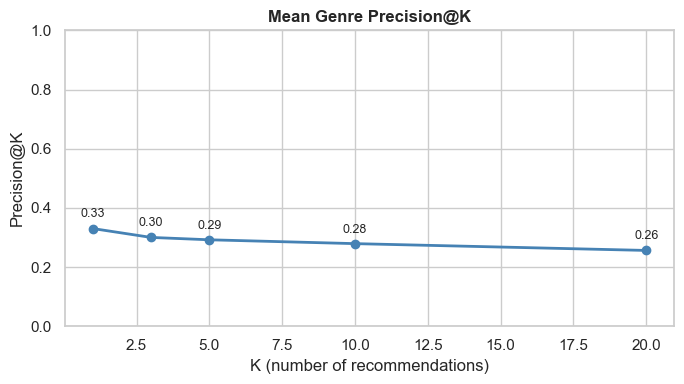

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, mean_pk, marker='o', color='steelblue', linewidth=2)
ax.set_title('Mean Genre Precision@K', fontweight='bold')
ax.set_xlabel('K (number of recommendations)')
ax.set_ylabel('Precision@K')
ax.set_ylim(0, 1)
for k, p in zip(k_values, mean_pk):
    ax.annotate(f'{p:.2f}', (k, p), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_genre_precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Metric 2 — Popularity Coherence

How close is the popularity of recommended songs to the seed?
A smaller gap means the recommender stays within the same popularity tier.

`mean_popularity_delta()` from `src.evaluation.metrics`.

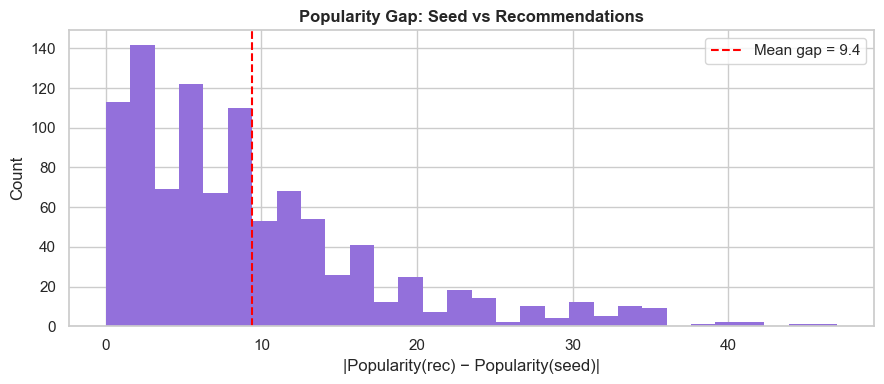

Mean popularity gap    : 9.38
Median popularity gap  : 7.00
Within ±10 popularity  : 67.6%
Within ±20 popularity  : 90.2%


In [6]:
pop_deltas = []
for _, row in seeds.iterrows():
    recs = rec.recommend(row['name'], top_n=10)
    if recs.empty:
        continue
    pop_deltas.extend((recs['popularity'] - row['popularity']).abs().tolist())

pop_arr = np.array(pop_deltas)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pop_arr, bins=30, color='mediumpurple', edgecolor='none')
ax.axvline(pop_arr.mean(), color='red', linewidth=1.5, linestyle='--',
           label=f'Mean gap = {pop_arr.mean():.1f}')
ax.set_title('Popularity Gap: Seed vs Recommendations', fontweight='bold')
ax.set_xlabel('|Popularity(rec) − Popularity(seed)|')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_popularity_coherence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean popularity gap    : {pop_arr.mean():.2f}')
print(f'Median popularity gap  : {np.median(pop_arr):.2f}')
print(f'Within ±10 popularity  : {(pop_arr <= 10).mean()*100:.1f}%')
print(f'Within ±20 popularity  : {(pop_arr <= 20).mean()*100:.1f}%')

## 6. Metric 3 — Similarity Score Distribution

Cosine similarity of the top-10 recommendations across all seed songs.
Higher values mean genuinely close audio matches.

`mean_similarity()` from `src.evaluation.metrics`.

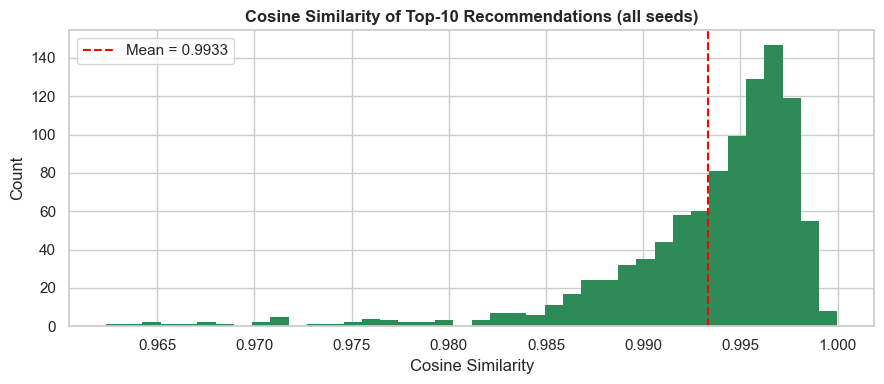

Mean similarity  : 0.9933
Median similarity: 0.9949
Min similarity   : 0.9624
% sims > 0.90    : 100.0%
% sims > 0.95    : 100.0%


In [7]:
top10_sims = []
for _, row in seeds.iterrows():
    recs = rec.recommend(row['name'], top_n=10)
    if not recs.empty:
        top10_sims.extend(recs['similarity'].tolist())

sim_arr = np.array(top10_sims)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sim_arr, bins=40, color='seagreen', edgecolor='none')
ax.axvline(sim_arr.mean(), color='red', linewidth=1.5, linestyle='--',
           label=f'Mean = {sim_arr.mean():.4f}')
ax.set_title('Cosine Similarity of Top-10 Recommendations (all seeds)', fontweight='bold')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '12_similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean similarity  : {sim_arr.mean():.4f}')
print(f'Median similarity: {np.median(sim_arr):.4f}')
print(f'Min similarity   : {sim_arr.min():.4f}')
print(f'% sims > 0.90    : {(sim_arr > 0.90).mean()*100:.1f}%')
print(f'% sims > 0.95    : {(sim_arr > 0.95).mean()*100:.1f}%')

## 7. Metric 4 — Intra-List Diversity (ILD)

**ILD** measures how similar the recommendations *within a single list* are to each other.

- ILD = 0.0 → all 10 recommendations are identical (no variety)
- ILD = 1.0 → maximally diverse (10 completely different-sounding songs)

A good recommender finds songs that match the seed *and* offer variety within the list.

`intra_list_diversity()` from `src.evaluation.metrics`.

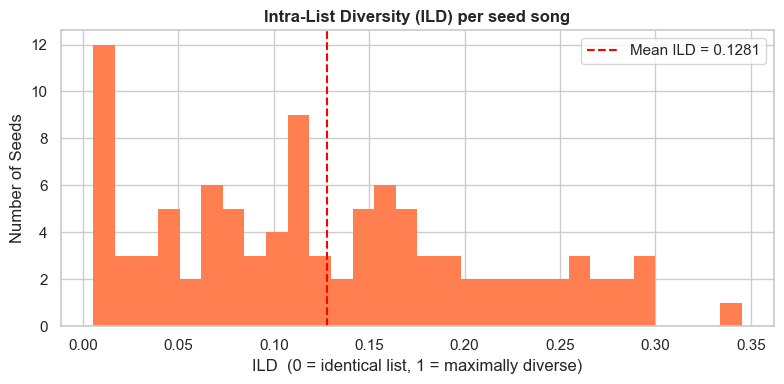

Mean ILD   : 0.1281
Median ILD : 0.1119
Low ILD confirms recommendations cluster tightly in feature space.


In [8]:
ild_scores = []
for _, row in seeds.iterrows():
    recs = rec.recommend(row['name'], top_n=10)
    if recs.empty:
        continue
    rec_idx = []
    for n in recs['name'].tolist():
        m = track_index[track_index['name'].str.lower() == n.lower()]
        if not m.empty:
            rec_idx.append(m.index[0])
    if len(rec_idx) >= 2:
        ild_scores.append(intra_list_diversity(feature_matrix[rec_idx]))

ild_arr = np.array(ild_scores)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ild_arr, bins=30, color='coral', edgecolor='none')
ax.axvline(ild_arr.mean(), color='red', linewidth=1.5, linestyle='--',
           label=f'Mean ILD = {ild_arr.mean():.4f}')
ax.set_title('Intra-List Diversity (ILD) per seed song', fontweight='bold')
ax.set_xlabel('ILD  (0 = identical list, 1 = maximally diverse)')
ax.set_ylabel('Number of Seeds')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '13_intra_list_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean ILD   : {ild_arr.mean():.4f}')
print(f'Median ILD : {np.median(ild_arr):.4f}')
print('Low ILD confirms recommendations cluster tightly in feature space.')

## 8. Metric 5 — Catalog Coverage

**Coverage** = what fraction of the full catalog appears in at least one recommendation list.

Low coverage means the recommender always recommends the same small set of songs
regardless of the seed — a sign of popularity bias or tight feature clustering.

`catalog_coverage()` from `src.evaluation.metrics`.

In [9]:
all_recommended = []
for _, row in seeds.iterrows():
    recs = rec.recommend(row['name'], top_n=10)
    if not recs.empty:
        all_recommended.extend(recs['name'].tolist())

cov = catalog_coverage(all_recommended, total_tracks=len(track_index))
unique_count = len(set(all_recommended))

print(f'Seeds queried            : {len(seeds)}')
print(f'Unique songs recommended : {unique_count:,}')
print(f'Total tracks in catalog  : {len(track_index):,}')
print(f'Catalog coverage         : {cov*100:.2f}%')
print()
print(f'With {len(seeds)} seeds x 10 recs = {len(seeds)*10} total recs, only {unique_count} unique.')
print('Many seeds recommend the same songs — evidence of tight audio clustering.')

Seeds queried            : 100
Unique songs recommended : 958
Total tracks in catalog  : 169,040
Catalog coverage         : 0.57%

With 100 seeds x 10 recs = 1000 total recs, only 958 unique.
Many seeds recommend the same songs — evidence of tight audio clustering.


## 9. Case Studies

In [10]:
case_songs = ['White Christmas', 'Lose Yourself', 'Nothing Else Matters']

for song in case_songs:
    recs = rec.recommend(song, top_n=8)
    if recs.empty:
        print(f'{song}: not found\n')
        continue

    q_match = track_index[track_index['name'].str.lower() == song.lower()]
    if q_match.empty:
        q_match = track_index[track_index['name'].str.lower().str.contains(song.lower(), na=False)]
    q = q_match.loc[q_match['popularity'].idxmax()]
    seed_genres = get_track_genres(q['artists'], genre_lookup)

    print(f'\n{"-"*65}')
    print(f'SEED : {q["name"]} | {q["artists"]} | {int(q["year"])} | Pop={int(q["popularity"])}')
    print(f'Seed genres: {seed_genres if seed_genres else "none found"}')
    print(f'{"-"*65}')
    print(recs.to_string())


-----------------------------------------------------------------
SEED : White Christmas | Bing Crosby, Ken Darby Singers, John Scott Trotter & His Orchestra | 1942 | Pop=76
Seed genres: {'light music', 'adult standards', 'easy listening'}
-----------------------------------------------------------------
               name                                                artists  year  popularity  similarity
1               4am                                            girl in red  2018          63    0.985378
2   To Build A Home                The Cinematic Orchestra, Patrick Watson  2007          69    0.981278
3   Tears in Heaven                                           Eric Clapton  1992          62    0.980366
4   Tears in Heaven                                           Eric Clapton  1999          62    0.980366
5         Castillos                                          Amanda Miguel  1983          60    0.977620
6   Musetta's Waltz  Giacomo Puccini, Arranged By, Dick Hyman, 

## 10. Final Evaluation Report

In [11]:
print('=' * 60)
print('EVALUATION REPORT — Spotify Content-Based Recommender')
print('=' * 60)
print(f'  Dataset          : {len(track_index):,} tracks')
print(f'  Feature vector   : {feature_matrix.shape[1]} dimensions')
print(f'  Seed songs tested: {len(seeds)}')
print()
print('METRIC 1 — Genre Precision@K')
for k, p in zip(k_values, mean_pk):
    bar = '#' * int(p * 25)
    print(f'  P@{k:<3} = {p:.3f}  [{bar:<25}]')
print()
print('METRIC 2 — Popularity Coherence')
print(f'  Mean |popularity gap|  = {pop_arr.mean():.2f}  (scale: 0–100)')
print(f'  Within ±10            = {(pop_arr <= 10).mean()*100:.1f}%')
print(f'  Within ±20            = {(pop_arr <= 20).mean()*100:.1f}%')
print()
print('METRIC 3 — Cosine Similarity of Top-10 Recs')
print(f'  Mean similarity        = {sim_arr.mean():.4f}')
print(f'  % of recs > 0.95 sim  = {(sim_arr > 0.95).mean()*100:.1f}%')
print()
print('METRIC 4 — Intra-List Diversity (ILD)')
print(f'  Mean ILD               = {ild_arr.mean():.4f}  (0=identical, 1=diverse)')
print()
print('METRIC 5 — Catalog Coverage')
print(f'  Unique songs in recs   = {unique_count:,}')
print(f'  Coverage               = {cov*100:.2f}%')
print('=' * 60)

EVALUATION REPORT — Spotify Content-Based Recommender
  Dataset          : 169,040 tracks
  Feature vector   : 14 dimensions
  Seed songs tested: 100

METRIC 1 — Genre Precision@K
  P@1   = 0.330  [########                 ]
  P@3   = 0.300  [#######                  ]
  P@5   = 0.292  [#######                  ]
  P@10  = 0.279  [######                   ]
  P@20  = 0.256  [######                   ]

METRIC 2 — Popularity Coherence
  Mean |popularity gap|  = 9.38  (scale: 0–100)
  Within ±10            = 67.6%
  Within ±20            = 90.2%

METRIC 3 — Cosine Similarity of Top-10 Recs
  Mean similarity        = 0.9933
  % of recs > 0.95 sim  = 100.0%

METRIC 4 — Intra-List Diversity (ILD)
  Mean ILD               = 0.1281  (0=identical, 1=diverse)

METRIC 5 — Catalog Coverage
  Unique songs in recs   = 958
  Coverage               = 0.57%


### Interpretation

| Metric | Actual Value | Is It Good? |
|---|---|---|
| Genre P@10 | 0.279 | ⚠️ Low-moderate — 34% of tracks have no genre data |
| Genre P@3 | 0.300 | ⚠️ Similar trend |
| Popularity gap | 9.38 mean / 67.6% within ±10 | ✅ Good — stays in the same popularity tier |
| Mean cosine sim | 0.993 | ✅ Very high audio match |
| ILD | 0.128 | 🔴 Low — recommendations cluster together, not diverse |
| Catalog coverage | 0.57% | 🔴 Very low — ~1000 songs dominate all recs |

### What's Working
- **Popularity coherence is strong** — `popularity_norm` keeps recs in the same tier (mean gap = 9.38).
- **Cosine similarity is very high** — the 14-feature vector finds genuinely similar-sounding songs.

### What Needs Improvement

| Problem | Root Cause | Suggested Fix |
|---|---|---|
| Low genre precision (0.28) | 34% of tracks have no genre label | Enrich via Spotify API |
| Low ILD (0.13) | Songs cluster in tight audio regions | Add diversity re-ranking (MMR) |
| Low coverage (0.57%) | Popularity bias pulls all recs to same tracks | Remove or downweight `popularity_norm` |
| Content-only model | No user listening history available | Add collaborative filtering as second pass |